# EDA — input_data.csv (2021)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Загрузка данных

In [2]:
df = pd.read_csv('../data/raw/input_data.csv', sep=';')
print('Shape:', df.shape)
df.head()

Shape: (11358150, 15)


,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
0,2021-01-01,2451300,15,31,1,30.3,0.0,56.780112,60.699355,0,2,620000.0,NaN,66,1632918.0
1,2021-01-01,1450000,5,5,1,33.0,6.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN
2,2021-01-01,10700000,4,13,3,85.0,12.0,55.540060,37.725112,3,0,142701.0,242543.0,50,681306.0
3,2021-01-01,3100000,3,5,3,82.0,9.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN
4,2021-01-01,2500000,2,3,1,30.0,9.0,44.738685,37.713668,3,2,353960.0,439378.0,23,1730985.0


In [3]:
df.dtypes

date                 str
price              int64
level              int64
levels             int64
rooms              int64
area             float64
kitchen_area     float64
geo_lat          float64
geo_lon          float64
building_type      int64
object_type        int64
postal_code      float64
street_id        float64
id_region          int64
house_id         float64
dtype: object

In [4]:
df.isnull().sum()

date                   0
price                  0
level                  0
levels                 0
rooms                  0
area                   0
kitchen_area           0
geo_lat                0
geo_lon                0
building_type          0
object_type            0
postal_code       507771
street_id        4205554
id_region              0
house_id         3261943
dtype: int64

## 2. Целевая переменная — цена

In [5]:
df['price'].describe()

count    1.135815e+07
mean     6.787516e+06
std      1.977118e+08
min      0.000000e+00
25%      2.600000e+06
50%      3.995000e+06
75%      6.500000e+06
max      6.355524e+11
Name: price, dtype: float64

In [6]:
print('Нулевые цены:', (df['price'] == 0).sum())
print('Цены > 1 млрд:', (df['price'] > 1_000_000_000).sum())

Нулевые цены: 8100
Цены > 1 млрд: 1032


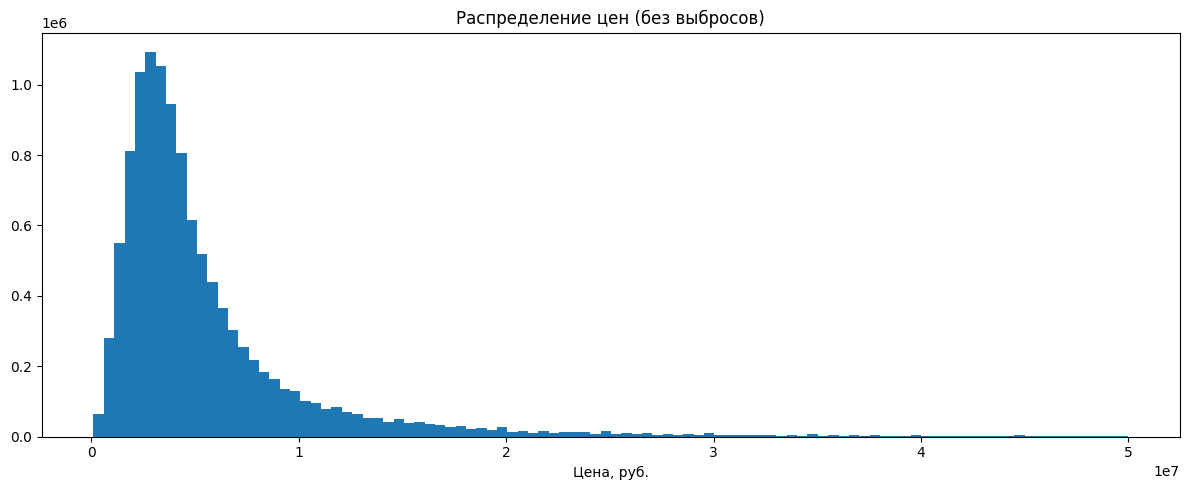

In [7]:
price_clean = df[(df['price'] > 100_000) & (df['price'] < 50_000_000)]['price']
plt.figure()
plt.hist(price_clean, bins=100)
plt.title('Распределение цен (без выбросов)')
plt.xlabel('Цена, руб.')
plt.tight_layout()
plt.show()

## 3. Временной анализ

In [8]:
df['date'] = pd.to_datetime(df['date'])
print('Период:', df['date'].min(), '—', df['date'].max())
df['date'].dt.month.value_counts().sort_index()

Период: 2021-01-01 00:00:00 — 2021-12-31 00:00:00


date
1      573392
2      952797
3     1029609
4      986010
5      866994
6      889305
7     1101639
8     1057168
9     1014866
10    1015469
11    1014692
12     856209
Name: count, dtype: int64

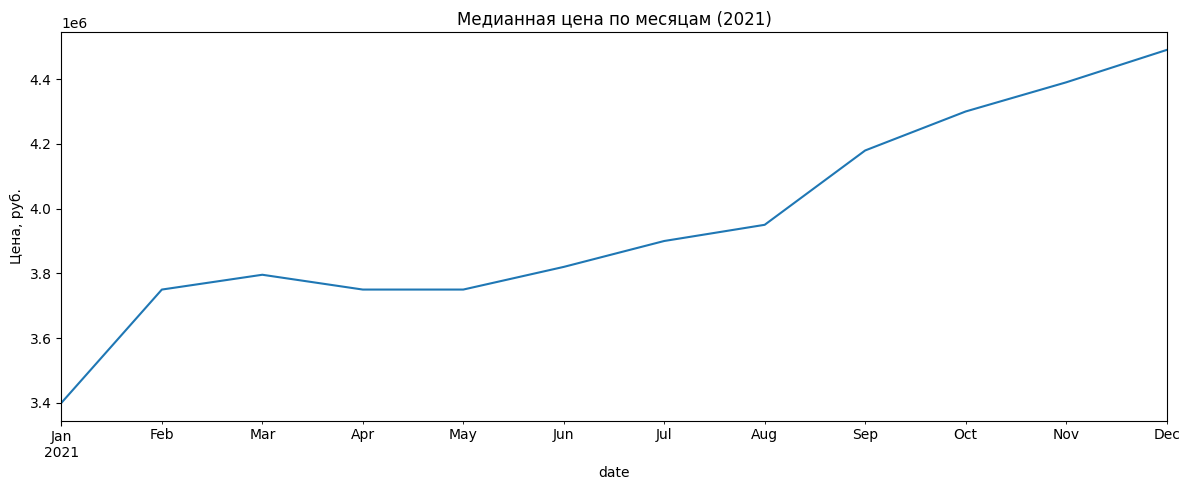

In [9]:
monthly = df[(df['price'] > 100_000) & (df['price'] < 50_000_000)].groupby(
    df['date'].dt.to_period('M'))['price'].median()
monthly.plot(title='Медианная цена по месяцам (2021)')
plt.ylabel('Цена, руб.')
plt.tight_layout()
plt.show()

## 4. Признаки

In [10]:
for col in ['building_type', 'object_type', 'rooms']:
    print(f'{col}: {sorted(df[col].unique())}')

building_type: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
object_type: [np.int64(0), np.int64(2)]
rooms: [np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [11]:
print('Кол-во уникальных регионов (id_region):', df['id_region'].nunique())
print('Топ-10 регионов по кол-ву объявлений:')
print(df['id_region'].value_counts().head(10))

Кол-во уникальных регионов (id_region): 86
Топ-10 регионов по кол-ву объявлений:
id_region
77    1032600
72     865423
23     846948
78     765872
50     754267
54     607520
24     432407
66     430999
61     409162
74     329235
Name: count, dtype: int64


In [12]:
# Пропуски в postal_code, street_id, house_id
extra_cols = ['postal_code', 'street_id', 'house_id']
print('Пропуски в доп. колонках:')
print(df[extra_cols].isnull().sum())
print('% пропусков:')
print((df[extra_cols].isnull().sum() / len(df) * 100).round(1))

Пропуски в доп. колонках:
postal_code     507771
street_id      4205554
house_id       3261943
dtype: int64
% пропусков:
postal_code     4.5
street_id      37.0
house_id       28.7
dtype: float64


In [13]:
df[['area', 'kitchen_area']].describe()

,area,kitchen_area
count,1.135815e+07,1.135815e+07
mean,5.310356e+01,-2.674071e+00
std,2.712845e+01,3.241855e+01
min,1.000000e+00,-1.000000e+02
25%,3.650000e+01,0.000000e+00
50%,4.670000e+01,6.500000e+00
75%,6.300000e+01,1.050000e+01
max,4.999000e+02,4.080000e+02


## 5. Корреляции

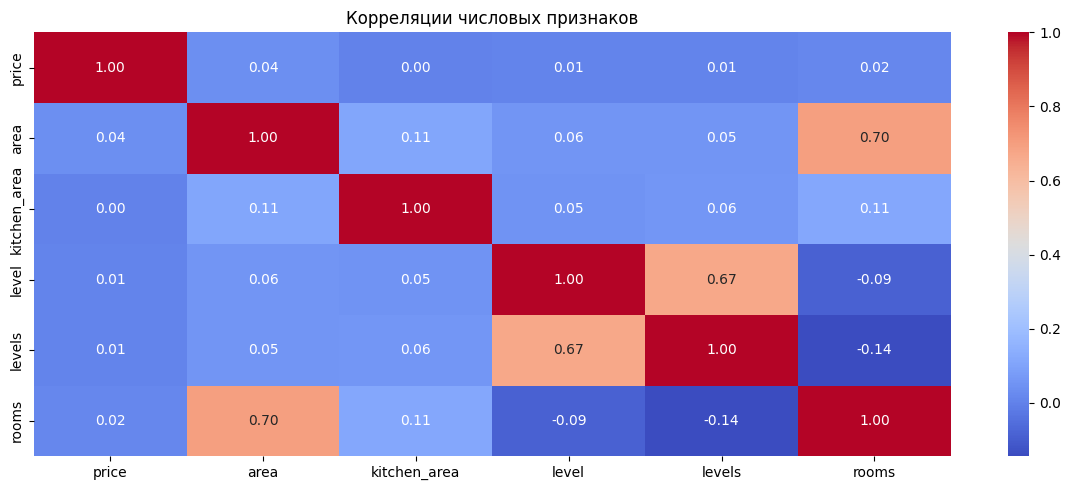

In [14]:
num_cols = ['price', 'area', 'kitchen_area', 'level', 'levels', 'rooms']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляции числовых признаков')
plt.tight_layout()
plt.show()

## 6. Сравнение с all_v2.csv — общие признаки

**Общие признаки:**
- date, price, level, levels, rooms, area, kitchen_area, geo_lat, geo_lon, building_type, object_type

**Только в all_v2:** time, region

**Только в input_data:** postal_code, street_id, id_region, house_id

**Важно:** region (all_v2) и id_region (input_data) — разные схемы кодирования регионов, нужно привести к единому виду.